In [ ]:
import subprocess
subprocess.run(["pip", "install", "-q", "--upgrade", "numpy>=2.0"], check=True)

CompletedProcess(args=['pip', 'install', '-q', '--upgrade', 'numpy>=2.0'], returncode=0)

In [ ]:
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers==4.40.0",
                "tokenizers==0.19.1",
                "sentence-transformers==2.7.0",
                "--force-reinstall"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "numpy==2.0.2",
                "--force-reinstall"], check=True)

print("Done — now Runtime > Restart session")

Done — now Runtime > Restart session


### Mount Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR   = "/content/drive/MyDrive/agentic-rag-telecom-thesis"
RESULTS    = f"{BASE_DIR}/results"
TRACES_DIR = f"{RESULTS}/traces"
CHROMA_DIR = f"{RESULTS}/chroma_baseline"   # reuse existing index

import os
os.makedirs(TRACES_DIR, exist_ok=True)
print("Drive mounted. BASE_DIR:", BASE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. BASE_DIR: /content/drive/MyDrive/agentic-rag-telecom-thesis


### Dependencies

In [ ]:
import subprocess, sys

def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + list(args))

pip("sentence-transformers")
pip("chromadb")
pip("rank-bm25")
pip("openai", "langchain-openai")
pip("ragas", "datasets")
pip("evaluate", "sacrebleu", "rouge-score")
pip("pandas", "matplotlib")

### Imports & Config

In [ ]:

import os, json, re, time, csv, random
import numpy as np

print(f"numpy version: {np.__version__}")

from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
assert os.environ.get("OPENAI_API_KEY"), "Set OPENAI_API_KEY in Colab Secrets"

SEED            = 42
N_QA            = 50
N_RAGAS         = 50
TOP_K_RETRIEVAL = 10
TOP_K_FINAL     = 5
GENERATOR_MODEL = "gpt-4o-mini"
RAGAS_JUDGE     = "gpt-4o-mini"
RAGAS_EMB       = "text-embedding-3-small"

random.seed(SEED)
# np.random.seed removed — not needed without torch

print(f"Config: N_QA={N_QA} | N_RAGAS={N_RAGAS} | Generator: {GENERATOR_MODEL}")

numpy version: 2.0.2
Config: N_QA=50 | N_RAGAS=50 | Generator: gpt-4o-mini


### Loading Existing QA Pairs from Baseline Traces

In [ ]:
BASELINE_TRACE = f"{TRACES_DIR}/baseline_traces.jsonl"
assert os.path.exists(BASELINE_TRACE), f"Missing: {BASELINE_TRACE}"

rows      = [json.loads(l) for l in open(BASELINE_TRACE, encoding="utf-8")][:N_QA]
questions = [r["query"]     for r in rows]
refs      = [r["reference"] for r in rows]

print(f"Loaded {len(questions)} QA pairs from baseline traces.")
print(f"Sample Q: {questions[0][:80]}...")
print(f"Sample A: {refs[0][:80]}...")

Loaded 50 QA pairs from baseline traces.
Sample Q: I do have an enhanced document and I am trying to find the document number....
Sample A: It is located in the top line of the Machine Readable Zone and is the 10 alpha-n...


### Loading Existing Chroma Index

In [ ]:
CHROMA_DIR = f"{RESULTS}/chroma_baseline"

In [ ]:
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "-q",
#                 "sentence-transformers==3.0.1",
#                 "--force-reinstall"], check=True)
# print("Done")

In [ ]:
import chromadb
from sentence_transformers import SentenceTransformer, CrossEncoder

# Dense embedder — same as original

dense_emb = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Reranker — cross-encoder for Context Precision improvement
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
print("Cross-encoder reranker loaded: cross-encoder/ms-marco-MiniLM-L-6-v2")

# Open existing Chroma collection (no rebuilding needed)
chroma_client = chromadb.PersistentClient(path=CHROMA_DIR)
col = chroma_client.get_collection("doc2dial_baseline")
print(f"Chroma collection 'doc2dial_baseline' opened. Count: {col.count()} chunks")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Cross-encoder reranker loaded: cross-encoder/ms-marco-MiniLM-L-6-v2
Chroma collection 'doc2dial_baseline' opened. Count: 2886 chunks


### BM25 Index (Hybrid Retrieval)

In [ ]:
# Build BM25 index over all documents in Chroma.
# This only needs to run once — takes ~30s for 2886 chunks.

from rank_bm25 import BM25Okapi

print("Building BM25 index over all Chroma chunks...")
t0 = time.time()

# Fetch all documents from Chroma for BM25
all_data  = col.get(include=["documents", "metadatas"])
all_docs  = all_data["documents"]      # list of chunk texts
all_metas = all_data["metadatas"]      # list of {doc_id, chunk_id}
all_ids   = all_data["ids"]            # list of IDs

# Tokenise for BM25
tokenised_corpus = [doc.lower().split() for doc in all_docs]
bm25 = BM25Okapi(tokenised_corpus)

print(f"BM25 index built over {len(all_docs)} chunks in {time.time()-t0:.1f}s")

Building BM25 index over all Chroma chunks...
BM25 index built over 2886 chunks in 0.9s


### Hybrid Retrieval + Reranking Function

In [ ]:
def hybrid_retrieve_rerank(query: str, k_fetch: int = TOP_K_RETRIEVAL,
                            k_final: int = TOP_K_FINAL):
    """
    1. Dense retrieval: top k_fetch chunks via Chroma cosine similarity
    2. BM25 retrieval: top k_fetch chunks via BM25Okapi
    3. Reciprocal Rank Fusion (RRF) to merge rankings
    4. Cross-encoder reranking on top-20 RRF candidates
    5. Return top k_final chunks after reranking

    Returns: (docs, metas) — both lists of length k_final
    """
    # ── Step 1: Dense retrieval ──
    q_emb = dense_emb.encode([query], normalize_embeddings=True).tolist()[0]
    dense_res = col.query(
        query_embeddings=[q_emb],
        n_results=k_fetch,
        include=["documents", "metadatas"]  # removed "ids" — returned automatically
    )
    dense_ids   = dense_res["ids"][0]       # still accessible, just not in include
    dense_docs  = dense_res["documents"][0]
    dense_metas = dense_res["metadatas"][0]

    # Map ID → (doc, meta) for dense results
    dense_map = {
        id_: (doc, meta)
        for id_, doc, meta in zip(dense_ids, dense_docs, dense_metas)
    }

    # ── Step 2: BM25 retrieval ──
    tokens    = query.lower().split()
    bm25_scores = bm25.get_scores(tokens)
    top_bm25_idx = np.argsort(bm25_scores)[::-1][:k_fetch]

    bm25_map = {}  # ID → (doc, meta, bm25_rank)
    for rank, idx in enumerate(top_bm25_idx):
        id_   = all_ids[idx]
        doc   = all_docs[idx]
        meta  = all_metas[idx]
        bm25_map[id_] = (doc, meta, rank)

    # ── Step 3: Reciprocal Rank Fusion ──
    # RRF score = Σ 1/(k + rank) for each list, k=60 is standard
    RRF_K = 60
    rrf_scores = {}

    for rank, id_ in enumerate(dense_ids):
        rrf_scores[id_] = rrf_scores.get(id_, 0.0) + 1.0 / (RRF_K + rank)

    for rank, idx in enumerate(top_bm25_idx):
        id_ = all_ids[idx]
        rrf_scores[id_] = rrf_scores.get(id_, 0.0) + 1.0 / (RRF_K + rank)

    # Sort by RRF score, take top 20 candidates for reranking
    rrf_ranked = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)[:20]

    # Collect candidate texts + metadata
    candidates = []
    for id_, _ in rrf_ranked:
        if id_ in dense_map:
            doc, meta = dense_map[id_]
        elif id_ in bm25_map:
            doc, meta, _ = bm25_map[id_]
        else:
            # Fetch from Chroma if only in BM25
            fetched = col.get(ids=[id_], include=["documents", "metadatas"])
            if not fetched["documents"]:
                continue
            doc  = fetched["documents"][0]
            meta = fetched["metadatas"][0]
        candidates.append((id_, doc, meta))

    if not candidates:
        # Fallback: return dense results only
        return dense_docs[:k_final], dense_metas[:k_final]

    # ── Step 4: Cross-encoder reranking ──
    pairs = [(query, cand[1][:512]) for cand in candidates]  # truncate for speed
    ce_scores = reranker.predict(pairs)

    # Sort by cross-encoder score descending
    reranked = sorted(zip(ce_scores, candidates), key=lambda x: x[0], reverse=True)

    # ── Step 5: Return top k_final ──
    top = reranked[:k_final]
    final_docs  = [item[1][1] for item in top]
    final_metas = [item[1][2] for item in top]

    return final_docs, final_metas


# Quick smoke test
test_docs, test_metas = hybrid_retrieve_rerank(questions[0])
print(f"Hybrid+rerank smoke test passed. Returned {len(test_docs)} chunks.")
print(f"First chunk preview: {test_docs[0][:120]}...")

Hybrid+rerank smoke test passed. Returned 5 chunks.
First chunk preview: MV office , you will be required to pay the amendment fee as required by the Vehicle and Traffic Law $12.50 for driver l...


### GPT-5.4-mini Generator

In [ ]:
from openai import OpenAI

oai_client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

def generate_answer(context: str, question: str,
                    system_prompt: str = None,
                    model: str = GENERATOR_MODEL,
                    max_tokens: int = 512) -> str:
    """
    Call GPT-5.4-mini with a context + question prompt.
    Returns the generated answer string.
    """
    if system_prompt is None:
        system_prompt = (
            "You are a helpful customer support assistant. "
            "Answer the question using ONLY the provided context. "
            "If the answer is not in the context, say: I don't know. "
            "Be concise and precise. Do not fabricate information."
        )

    user_msg = (
        f"CONTEXT:\n{context}\n\n"
        f"QUESTION: {question}\n\n"
        f"ANSWER:"
    )

    resp = oai_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_msg},
        ],
        max_tokens=max_tokens,
        temperature=0,   # deterministic
    )
    return resp.choices[0].message.content.strip()


# Quick smoke test
test_ctx  = test_docs[0][:500]
test_ans  = generate_answer(test_ctx, questions[0])
print(f"GPT-5.4-mini smoke test passed.")
print(f"Answer: {test_ans[:150]}...")

GPT-5.4-mini smoke test passed.
Answer: The document number for your enhanced document is located in the top line of the Machine Readable Zone and is the 10 alpha-numeric digits that appear ...


### Improved Baseline RAG

In [ ]:
# Same single-pass pattern but now with:
#   - Hybrid retrieval + reranking
#   - GPT-5.4-mini generator

import evaluate as hf_evaluate

rouge_metric = hf_evaluate.load("rouge")
bleu_metric  = hf_evaluate.load("sacrebleu")

BASELINE_IMP_TRACE = f"{TRACES_DIR}/baseline_improved_traces.jsonl"
BASELINE_IMP_CSV   = f"{RESULTS}/baseline_improved_summary.csv"

print("Running Improved Baseline RAG...")
preds_base, lats_base = [], []

with open(BASELINE_IMP_TRACE, "w", encoding="utf-8") as f:
    for i, (q, ref) in enumerate(zip(questions, refs), 1):
        t0 = time.time()

        # Hybrid retrieve + rerank
        docs, metas = hybrid_retrieve_rerank(q, k_fetch=TOP_K_RETRIEVAL,
                                              k_final=TOP_K_FINAL)

        # Format context with source tags
        context = "\n\n".join([
            f"[{m.get('doc_id','?')}#{m.get('chunk_id','?')}] {d}"
            for d, m in zip(docs, metas)
        ])

        # Generate with GPT-5.4-mini
        ans = generate_answer(context, q)
        dt  = time.time() - t0

        preds_base.append(ans)
        lats_base.append(dt)

        record = {
            "i": i, "query": q, "prediction": ans, "reference": ref,
            "latency_s": float(dt), "top_k": TOP_K_FINAL,
            "retrieved": [{"doc_id": m.get("doc_id"), "chunk_id": m.get("chunk_id")}
                          for m in metas],
            "contexts": docs,
        }
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

        if i % 10 == 0:
            print(f"  {i}/{N_QA} done | last latency: {dt:.2f}s")

# Compute BLEU / ROUGE-L
rou_base = rouge_metric.compute(predictions=preds_base, references=refs, use_stemmer=True)
ble_base = bleu_metric.compute(predictions=preds_base, references=[[r] for r in refs])
lm_base  = float(np.mean(lats_base))
lmed_base = float(np.median(lats_base))
lp95_base = float(np.percentile(lats_base, 95))

print("\n=== Improved Baseline RAG ===")
print(f"ROUGE-L : {rou_base['rougeL']:.4f}")
print(f"BLEU    : {ble_base['score']:.4f}")
print(f"Latency : mean={lm_base:.2f}s | median={lmed_base:.2f}s | p95={lp95_base:.2f}s")

with open(BASELINE_IMP_CSV, "w", newline="", encoding="utf-8") as fp:
    w = csv.DictWriter(fp, fieldnames=["system","rougeL","bleu",
                                        "lat_mean_s","lat_median_s","lat_p95_s","n_pairs"])
    w.writeheader()
    w.writerow({"system":"Baseline-Improved","rougeL":rou_base['rougeL'],
                "bleu":ble_base['score'],"lat_mean_s":lm_base,
                "lat_median_s":lmed_base,"lat_p95_s":lp95_base,"n_pairs":N_QA})
print(f"Saved: {BASELINE_IMP_CSV}")

Running Improved Baseline RAG...
  10/50 done | last latency: 1.87s
  20/50 done | last latency: 2.63s
  30/50 done | last latency: 1.68s
  40/50 done | last latency: 0.51s
  50/50 done | last latency: 0.47s

=== Improved Baseline RAG ===
ROUGE-L : 0.1888
BLEU    : 11.0269
Latency : mean=1.39s | median=1.24s | p95=2.75s
Saved: /content/drive/MyDrive/agentic-rag-telecom-thesis/results/baseline_improved_summary.csv


### Improved ReAct

In [ ]:
# ReAct with GPT-5.4-mini natively handles Thought/Action/Observation
# format much better than flan-t5-base ever could.

REACT_IMP_TRACE = f"{TRACES_DIR}/react_improved_traces.jsonl"
REACT_IMP_CSV   = f"{RESULTS}/react_improved_summary.csv"

REACT_SYSTEM = """You are a customer support assistant that reasons step by step.
For each step, write:
  Thought: what you need to find out
  Action: Search[your search query here]
  Observation: (this will be filled with retrieved context)

When you have enough information, write:
  Final: your complete answer based only on retrieved context

Rules:
- Use ONLY retrieved context to answer. Never fabricate.
- If context is insufficient after 3 steps, write: Final: I don't know.
- Keep each Thought and Action on one line."""

def react_answer_gpt(question: str, k_fetch: int = TOP_K_RETRIEVAL,
                     k_final: int = TOP_K_FINAL, max_steps: int = 3):
    """GPT-5.4-mini ReAct loop with hybrid retrieval + reranking."""
    messages = [
        {"role": "system", "content": REACT_SYSTEM},
        {"role": "user",   "content": f"Question: {question}"},
    ]

    steps_taken    = 0
    action_queries = []
    all_contexts   = []
    scratch        = ""

    for step in range(max_steps):
        # Ask GPT to reason
        resp = oai_client.chat.completions.create(
            model=GENERATOR_MODEL,
            messages=messages,
            max_tokens=300,
            temperature=0,
            stop=["Observation:"],  # stop before it hallucinates observations
        )
        out = resp.choices[0].message.content.strip()
        scratch += "\n" + out

        # Check for Final answer
        if "Final:" in out:
            final_ans = out.split("Final:", 1)[1].strip()
            return final_ans, steps_taken + 1, action_queries, all_contexts

        # Extract Action: Search[query]
        action_match = re.search(r"Action:\s*Search\[(.+?)\]", out, re.IGNORECASE)
        if action_match:
            search_q = action_match.group(1).strip()
        elif steps_taken == 0:
            # Force first search using the original question
            search_q = question
        else:
            # No action found — extract any quoted text or fall back
            quoted = re.search(r'"([^"]+)"', out)
            search_q = quoted.group(1) if quoted else question

        action_queries.append(search_q)
        steps_taken += 1

        # Retrieve + rerank
        docs, metas = hybrid_retrieve_rerank(search_q, k_fetch=k_fetch, k_final=k_final)
        all_contexts.extend(docs)

        # Build observation (truncate each chunk to 400 chars for context window)
        obs_parts = [f"{j+1}. [{m.get('doc_id')}#{m.get('chunk_id')}] {d[:400]}"
                     for j, (d, m) in enumerate(zip(docs, metas))]
        obs_text = "\n".join(obs_parts)

        # Append to conversation
        messages.append({"role": "assistant", "content": out})
        messages.append({"role": "user",      "content": f"Observation:\n{obs_text}\n\nContinue:"})

    # Loop exhausted — fallback single-pass
    context = "\n\n".join(all_contexts[:k_final]) if all_contexts else ""
    fallback = generate_answer(context, question) if context else "I don't know."
    return fallback, steps_taken, action_queries, all_contexts


print("Running Improved ReAct...")
preds_react, lats_react = [], []

with open(REACT_IMP_TRACE, "w", encoding="utf-8") as f:
    for i, (q, ref) in enumerate(zip(questions, refs), 1):
        t0 = time.time()
        ans, steps, aq, ctxs = react_answer_gpt(q)
        dt = time.time() - t0

        preds_react.append(ans)
        lats_react.append(dt)

        record = {
            "i": i, "query": q, "prediction": ans, "reference": ref,
            "latency_s": float(dt), "top_k": TOP_K_FINAL,
            "steps": steps, "action_queries": aq,
            "contexts": ctxs[:TOP_K_FINAL * 3],
            "retrieved": [],   # populated from context strings
        }
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

        if i % 10 == 0:
            print(f"  {i}/{N_QA} done | steps={steps} | latency={dt:.2f}s")

rou_react = rouge_metric.compute(predictions=preds_react, references=refs, use_stemmer=True)
ble_react = bleu_metric.compute(predictions=preds_react, references=[[r] for r in refs])
lm_react  = float(np.mean(lats_react))
lmed_react = float(np.median(lats_react))
lp95_react = float(np.percentile(lats_react, 95))

print("\n=== Improved ReAct ===")
print(f"ROUGE-L : {rou_react['rougeL']:.4f}")
print(f"BLEU    : {ble_react['score']:.4f}")
print(f"Latency : mean={lm_react:.2f}s | median={lmed_react:.2f}s | p95={lp95_react:.2f}s")

with open(REACT_IMP_CSV, "w", newline="", encoding="utf-8") as fp:
    w = csv.DictWriter(fp, fieldnames=["system","rougeL","bleu",
                                        "lat_mean_s","lat_median_s","lat_p95_s","n_pairs"])
    w.writeheader()
    w.writerow({"system":"ReAct-Improved","rougeL":rou_react['rougeL'],
                "bleu":ble_react['score'],"lat_mean_s":lm_react,
                "lat_median_s":lmed_react,"lat_p95_s":lp95_react,"n_pairs":N_QA})
print(f"Saved: {REACT_IMP_CSV}")

Running Improved ReAct...
  10/50 done | steps=3 | latency=5.34s
  20/50 done | steps=3 | latency=6.14s
  30/50 done | steps=3 | latency=7.87s
  40/50 done | steps=3 | latency=3.92s
  50/50 done | steps=3 | latency=3.41s

=== Improved ReAct ===
ROUGE-L : 0.1797
BLEU    : 9.8970
Latency : mean=4.60s | median=4.82s | p95=7.56s
Saved: /content/drive/MyDrive/agentic-rag-telecom-thesis/results/react_improved_summary.csv


### Improved Planner–Executor

In [ ]:
# GPT-5.4-mini is a capable planner — it will generate real
# multi-step, domain-anchored plans unlike flan-t5-base.

PLANNER_IMP_TRACE = f"{TRACES_DIR}/planner_improved_traces.jsonl"
PLANNER_IMP_CSV   = f"{RESULTS}/planner_improved_summary.csv"

PLANNER_SYSTEM = """You are a planning assistant for customer support.
Given a user question, write a concise plan of 2-3 search steps.
Each step should be a specific, searchable sub-question that will help answer the original question.
Output ONLY numbered steps, one per line. Example:
1. What are the eligibility requirements for X?
2. What is the process to apply for X?
3. Are there any exceptions or special conditions for X?"""

EXECUTOR_SYSTEM = """You are a customer support assistant.
Answer the QUESTION using ONLY the provided CONTEXT.
If the answer is not in the context, say: I don't know.
Be concise, accurate, and do not fabricate information."""

def make_plan_gpt(question: str, max_steps: int = 3) -> list:
    """Generate a search plan using GPT-5.4-mini."""
    resp = oai_client.chat.completions.create(
        model=GENERATOR_MODEL,
        messages=[
            {"role": "system", "content": PLANNER_SYSTEM},
            {"role": "user",   "content": f"QUESTION: {question}\nPLAN:"},
        ],
        max_tokens=200,
        temperature=0,
    )
    plan_txt = resp.choices[0].message.content.strip()

    # Extract numbered steps
    steps = []
    for line in plan_txt.splitlines():
        m = re.match(r"^\s*\d+[.)]\s*(.+)$", line.strip())
        if m:
            steps.append(m.group(1).strip())

    # Fallback: if no steps parsed, use original question
    return steps[:max_steps] if steps else [question]


def planner_executor_answer_gpt(question: str, k_fetch: int = TOP_K_RETRIEVAL,
                                 k_final: int = TOP_K_FINAL):
    """Full Planner–Executor with GPT planning and hybrid retrieval."""
    t0 = time.time()

    # Stage 1: Plan
    steps = make_plan_gpt(question)

    # Stage 2: Execute — retrieve per step, deduplicate
    action_queries = []
    all_docs, all_metas = [], []
    seen = set()

    for step in steps:
        action_queries.append(step)
        docs, metas = hybrid_retrieve_rerank(step, k_fetch=k_fetch, k_final=k_final)
        for d, m in zip(docs, metas):
            key = (m.get("doc_id"), m.get("chunk_id"))
            if key not in seen:
                seen.add(key)
                all_docs.append(d)
                all_metas.append(m)

    # Stage 3: Synthesise
    context = "\n\n".join([
        f"[{m.get('doc_id')}#{m.get('chunk_id')}] {d}"
        for d, m in zip(all_docs[:k_final * 3], all_metas[:k_final * 3])
    ])

    ans = generate_answer(
        context, question,
        system_prompt=EXECUTOR_SYSTEM,
    )
    dt = time.time() - t0

    return ans, dt, steps, action_queries, all_docs, all_metas


print("Running Improved Planner–Executor...")
preds_plan, lats_plan = [], []

with open(PLANNER_IMP_TRACE, "w", encoding="utf-8") as f:
    for i, (q, ref) in enumerate(zip(questions, refs), 1):
        ans, dt, steps, aq, ctxs, metas = planner_executor_answer_gpt(q)
        preds_plan.append(ans)
        lats_plan.append(dt)

        record = {
            "i": i, "query": q, "prediction": ans, "reference": ref,
            "latency_s": float(dt), "top_k": TOP_K_FINAL,
            "plan_steps": steps, "action_queries": aq,
            "contexts": ctxs[:TOP_K_FINAL * 3],
            "retrieved": [{"doc_id": m.get("doc_id"), "chunk_id": m.get("chunk_id")}
                          for m in metas],
        }
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

        if i % 10 == 0:
            print(f"  {i}/{N_QA} done | plan_steps={len(steps)} | latency={dt:.2f}s")

rou_plan = rouge_metric.compute(predictions=preds_plan, references=refs, use_stemmer=True)
ble_plan = bleu_metric.compute(predictions=preds_plan, references=[[r] for r in refs])
lm_plan  = float(np.mean(lats_plan))
lmed_plan = float(np.median(lats_plan))
lp95_plan = float(np.percentile(lats_plan, 95))

print("\n=== Improved Planner–Executor ===")
print(f"ROUGE-L : {rou_plan['rougeL']:.4f}")
print(f"BLEU    : {ble_plan['score']:.4f}")
print(f"Latency : mean={lm_plan:.2f}s | median={lmed_plan:.2f}s | p95={lp95_plan:.2f}s")

with open(PLANNER_IMP_CSV, "w", newline="", encoding="utf-8") as fp:
    w = csv.DictWriter(fp, fieldnames=["system","rougeL","bleu",
                                        "lat_mean_s","lat_median_s","lat_p95_s","n_pairs"])
    w.writeheader()
    w.writerow({"system":"Planner-Executor-Improved","rougeL":rou_plan['rougeL'],
                "bleu":ble_plan['score'],"lat_mean_s":lm_plan,
                "lat_median_s":lmed_plan,"lat_p95_s":lp95_plan,"n_pairs":N_QA})
print(f"Saved: {PLANNER_IMP_CSV}")

Running Improved Planner–Executor...
  10/50 done | plan_steps=3 | latency=3.38s
  20/50 done | plan_steps=3 | latency=4.26s
  30/50 done | plan_steps=3 | latency=4.44s
  40/50 done | plan_steps=3 | latency=1.80s
  50/50 done | plan_steps=3 | latency=1.91s

=== Improved Planner–Executor ===
ROUGE-L : 0.1822
BLEU    : 10.1090
Latency : mean=2.75s | median=2.53s | p95=4.40s
Saved: /content/drive/MyDrive/agentic-rag-telecom-thesis/results/planner_improved_summary.csv


### RAGAS Evaluation — ALL THREE SYSTEMS (N=50)

In [ ]:
# N=50 for stronger statistical confidence (was N=20 before)

from datasets import Dataset
from ragas import evaluate as ragas_evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from ragas.run_config import RunConfig

llm_eval = ChatOpenAI(model=RAGAS_JUDGE, temperature=0)
emb_eval = OpenAIEmbeddings(model=RAGAS_EMB)
rc       = RunConfig(max_workers=2, timeout=120)

def run_ragas(trace_path: str, system_name: str, n: int = N_RAGAS):
    """Load trace, build RAGAS dataset, evaluate, return DataFrame."""
    rows = [json.loads(l) for l in open(trace_path, encoding="utf-8")][:n]

    ds = Dataset.from_dict({
        "question":    [r["query"]       for r in rows],
        "answer":      [r["prediction"]  for r in rows],
        "contexts":    [r.get("contexts", []) for r in rows],
        "ground_truth":[r["reference"]   for r in rows],
    })

    print(f"\nRunning RAGAS for {system_name} (N={n})...")
    res = ragas_evaluate(
        ds,
        metrics=[faithfulness, answer_relevancy, context_precision],
        llm=llm_eval,
        embeddings=emb_eval,
        run_config=rc,
    )
    df = res.to_pandas()
    means = df[["faithfulness","answer_relevancy","context_precision"]].mean().to_dict()
    print(f"  Faithfulness    : {means['faithfulness']:.4f}")
    print(f"  Answer Relevance: {means['answer_relevancy']:.4f}")
    print(f"  Context Precision: {means['context_precision']:.4f}")

    out_csv = f"{RESULTS}/{system_name.lower().replace(' ','_')}_ragas_improved.csv"
    df.to_csv(out_csv, index=False)
    print(f"  Saved: {out_csv}")
    return df, means


df_base_r,  means_base  = run_ragas(BASELINE_IMP_TRACE,  "baseline_improved")
df_react_r, means_react = run_ragas(REACT_IMP_TRACE,     "react_improved")
df_plan_r,  means_plan  = run_ragas(PLANNER_IMP_TRACE,   "planner_improved")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/tmp/ipykernel_4602/57298851.py:5: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision
/tmp/ipykernel_4602/57298851.py:5: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import 


Running RAGAS for baseline_improved (N=50)...


Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]

  Faithfulness    : 0.5952
  Answer Relevance: 0.4208
  Context Precision: 0.4021
  Saved: /content/drive/MyDrive/agentic-rag-telecom-thesis/results/baseline_improved_ragas_improved.csv

Running RAGAS for react_improved (N=50)...


Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]

  Faithfulness    : 0.5867
  Answer Relevance: 0.3944
  Context Precision: 0.3500
  Saved: /content/drive/MyDrive/agentic-rag-telecom-thesis/results/react_improved_ragas_improved.csv

Running RAGAS for planner_improved (N=50)...


Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]

  Faithfulness    : 0.6456
  Answer Relevance: 0.4478
  Context Precision: 0.3628
  Saved: /content/drive/MyDrive/agentic-rag-telecom-thesis/results/planner_improved_ragas_improved.csv


### Side-by-Side Comparison

In [ ]:
# Print a clean results table comparing old vs new numbers.

print("\n" + "="*70)
print("IMPROVED RESULTS — ALL SYSTEMS (N=50 RAGAS)")
print("="*70)
print(f"{'Metric':<22} {'Baseline':>12} {'ReAct':>12} {'Planner–Exec':>14}")
print("-"*70)
for metric, key in [("Faithfulness","faithfulness"),
                     ("Answer Relevance","answer_relevancy"),
                     ("Context Precision","context_precision")]:
    print(f"{metric:<22} {means_base[key]:>12.4f} {means_react[key]:>12.4f} {means_plan[key]:>14.4f}")

print("-"*70)
print(f"{'BLEU (N=50)':<22} {ble_base['score']:>12.3f} {ble_react['score']:>12.3f} {ble_plan['score']:>14.3f}")
print(f"{'ROUGE-L (N=50)':<22} {rou_base['rougeL']:>12.4f} {rou_react['rougeL']:>12.4f} {rou_plan['rougeL']:>14.4f}")
print(f"{'Latency mean (s)':<22} {lm_base:>12.2f} {lm_react:>12.2f} {lm_plan:>14.2f}")
print(f"{'Latency p95 (s)':<22} {lp95_base:>12.2f} {lp95_react:>12.2f} {lp95_plan:>14.2f}")
print("="*70)

print("\nORIGINAL RESULTS (for comparison):")
print(f"{'Metric':<22} {'Baseline':>12} {'ReAct':>12} {'Planner–Exec':>14}")
print("-"*70)
orig = {
    "faithfulness":      [0.6354, 0.5500, 0.4956],
    "answer_relevancy":  [0.2279, 0.1584, 0.1749],
    "context_precision": [0.3235, 0.3733, 0.3577],
}
for metric, vals in orig.items():
    print(f"{metric:<22} {vals[0]:>12.4f} {vals[1]:>12.4f} {vals[2]:>14.4f}")
print("="*70)


IMPROVED RESULTS — ALL SYSTEMS (N=50 RAGAS)
Metric                     Baseline        ReAct   Planner–Exec
----------------------------------------------------------------------
Faithfulness                 0.5952       0.5867         0.6456
Answer Relevance             0.4208       0.3944         0.4478
Context Precision            0.4021       0.3500         0.3628
----------------------------------------------------------------------
BLEU (N=50)                  11.027        9.897         10.109
ROUGE-L (N=50)               0.1888       0.1797         0.1822
Latency mean (s)               1.39         4.60           2.75
Latency p95 (s)                2.75         7.56           4.40

ORIGINAL RESULTS (for comparison):
Metric                     Baseline        ReAct   Planner–Exec
----------------------------------------------------------------------
faithfulness                 0.6354       0.5500         0.4956
answer_relevancy             0.2279       0.1584         0.1749
co

### Save Master Comparison CSV

In [ ]:
import pandas as pd

comparison = {
    "System":    ["Baseline-Orig","ReAct-Orig","Planner-Orig",
                  "Baseline-Improved","ReAct-Improved","Planner-Improved"],
    "Generator": ["flan-t5-base"]*3 + [GENERATOR_MODEL]*3,
    "Retrieval": ["Dense only"]*3 + ["Hybrid+Rerank"]*3,
    "RAGAS_N":   [20]*3 + [50]*3,
    "Faithfulness":       [0.6354,0.5500,0.4956,
                           means_base["faithfulness"],
                           means_react["faithfulness"],
                           means_plan["faithfulness"]],
    "Answer_Relevance":   [0.2279,0.1584,0.1749,
                           means_base["answer_relevancy"],
                           means_react["answer_relevancy"],
                           means_plan["answer_relevancy"]],
    "Context_Precision":  [0.3235,0.3733,0.3577,
                           means_base["context_precision"],
                           means_react["context_precision"],
                           means_plan["context_precision"]],
    "BLEU":     [4.071,0.930,0.354,
                 ble_base["score"],ble_react["score"],ble_plan["score"]],
    "ROUGE_L":  [0.0991,0.0653,0.0449,
                 rou_base["rougeL"],rou_react["rougeL"],rou_plan["rougeL"]],
    "Lat_mean_s":[11.32,2.24,9.28,lm_base,lm_react,lm_plan],
    "Lat_p95_s": [28.48,9.13,22.12,lp95_base,lp95_react,lp95_plan],
}

df_compare = pd.DataFrame(comparison)
master_csv = f"{RESULTS}/master_comparison.csv"
df_compare.to_csv(master_csv, index=False)
print(f"Master comparison saved: {master_csv}")
print(df_compare.to_string(index=False))

Master comparison saved: /content/drive/MyDrive/agentic-rag-telecom-thesis/results/master_comparison.csv
           System    Generator     Retrieval  RAGAS_N  Faithfulness  Answer_Relevance  Context_Precision      BLEU  ROUGE_L  Lat_mean_s  Lat_p95_s
    Baseline-Orig flan-t5-base    Dense only       20      0.635400          0.227900           0.323500  4.071000 0.099100   11.320000  28.480000
       ReAct-Orig flan-t5-base    Dense only       20      0.550000          0.158400           0.373300  0.930000 0.065300    2.240000   9.130000
     Planner-Orig flan-t5-base    Dense only       20      0.495600          0.174900           0.357700  0.354000 0.044900    9.280000  22.120000
Baseline-Improved  gpt-4o-mini Hybrid+Rerank       50      0.595238          0.420839           0.402139 11.026880 0.188785    1.390084   2.751867
   ReAct-Improved  gpt-4o-mini Hybrid+Rerank       50      0.586667          0.394399           0.349987  9.897018 0.179669    4.600857   7.562197
 Planner-Impr

### Visualisations

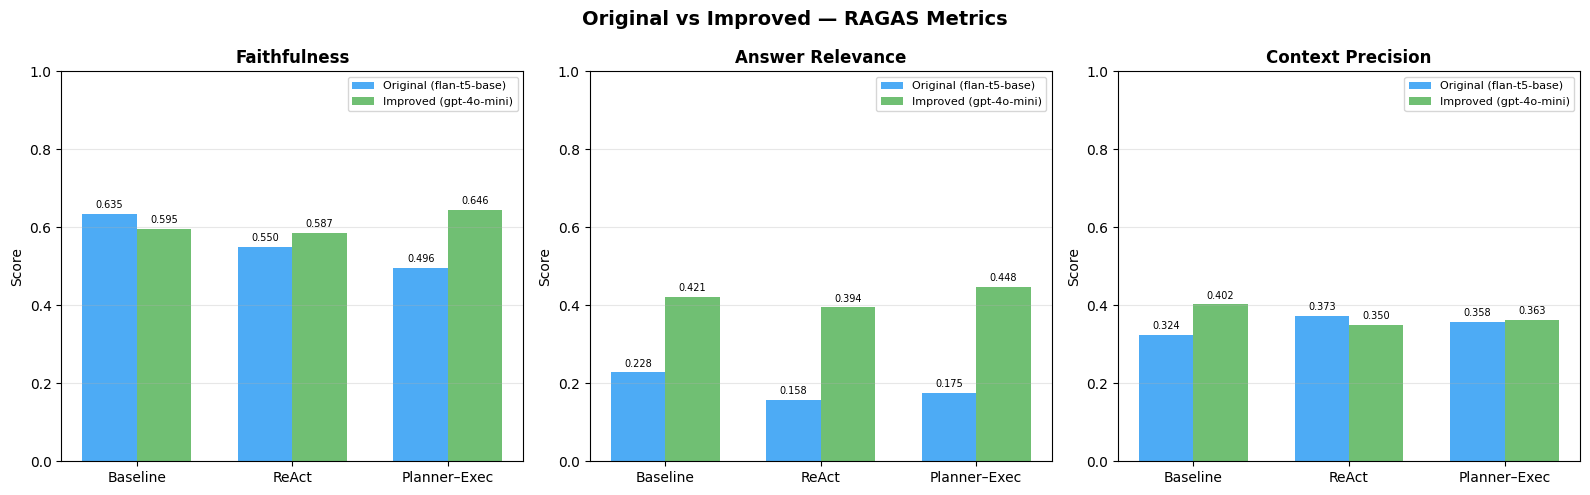

Saved: /content/drive/MyDrive/agentic-rag-telecom-thesis/results/ragas_comparison.png


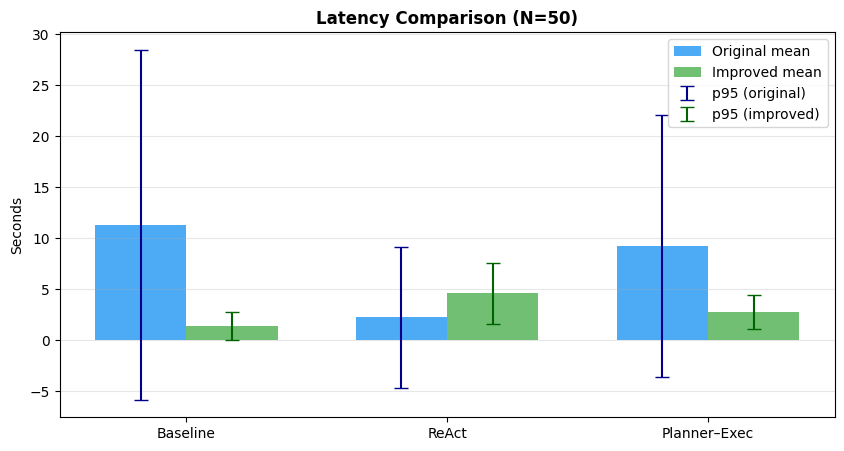

Saved: /content/drive/MyDrive/agentic-rag-telecom-thesis/results/latency_comparison.png

All done. Let's check your Google Drive results folder.
   /content/drive/MyDrive/agentic-rag-telecom-thesis/results/
   ├── baseline_improved_traces.jsonl
   ├── react_improved_traces.jsonl
   ├── planner_improved_traces.jsonl
   ├── *_improved_summary.csv  (BLEU/ROUGE/latency)
   ├── *_ragas_improved.csv    (RAGAS N=50)
   ├── master_comparison.csv   (old vs new side-by-side)
   ├── ragas_comparison.png
   └── latency_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Original vs Improved — RAGAS Metrics", fontsize=14, fontweight="bold")

systems  = ["Baseline", "ReAct", "Planner–Exec"]
x        = np.arange(len(systems))
width    = 0.35
colors   = ["#2196F3", "#4CAF50"]  # blue=original, green=improved

for ax, (metric_key, metric_label) in zip(axes, [
    ("Faithfulness",      "Faithfulness"),
    ("Answer_Relevance",  "Answer Relevance"),
    ("Context_Precision", "Context Precision"),
]):
    orig_vals = df_compare[df_compare["Generator"]=="flan-t5-base"][metric_key].values
    imp_vals  = df_compare[df_compare["Generator"]==GENERATOR_MODEL][metric_key].values

    bars1 = ax.bar(x - width/2, orig_vals, width, label="Original (flan-t5-base)",
                   color=colors[0], alpha=0.8)
    bars2 = ax.bar(x + width/2, imp_vals,  width, label=f"Improved ({GENERATOR_MODEL})",
                   color=colors[1], alpha=0.8)

    ax.set_title(metric_label, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(systems)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Score")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    # Annotate bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
fig.savefig(f"{RESULTS}/ragas_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS}/ragas_comparison.png")

# Latency comparison
fig2, ax2 = plt.subplots(figsize=(10, 5))
orig_lats = [11.32, 2.24, 9.28]
imp_lats  = [lm_base, lm_react, lm_plan]
orig_p95  = [28.48, 9.13, 22.12]
imp_p95   = [lp95_base, lp95_react, lp95_plan]

ax2.bar(x - width/2, orig_lats, width, label="Original mean", color=colors[0], alpha=0.8)
ax2.bar(x + width/2, imp_lats,  width, label="Improved mean", color=colors[1], alpha=0.8)
ax2.errorbar(x - width/2, orig_lats, yerr=[np.array(orig_p95)-np.array(orig_lats)],
             fmt="none", color="darkblue", capsize=5, label="p95 (original)")
ax2.errorbar(x + width/2, imp_lats,  yerr=[np.array(imp_p95)-np.array(imp_lats)],
             fmt="none", color="darkgreen", capsize=5, label="p95 (improved)")

ax2.set_title("Latency Comparison (N=50)", fontweight="bold")
ax2.set_xticks(x); ax2.set_xticklabels(systems)
ax2.set_ylabel("Seconds"); ax2.legend(); ax2.grid(axis="y", alpha=0.3)
fig2.savefig(f"{RESULTS}/latency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS}/latency_comparison.png")

print("\nAll done. Let's check your Google Drive results folder.")
print(f"   {RESULTS}/")
print("   ├── baseline_improved_traces.jsonl")
print("   ├── react_improved_traces.jsonl")
print("   ├── planner_improved_traces.jsonl")
print("   ├── *_improved_summary.csv  (BLEU/ROUGE/latency)")
print("   ├── *_ragas_improved.csv    (RAGAS N=50)")
print("   ├── master_comparison.csv   (old vs new side-by-side)")
print("   ├── ragas_comparison.png")
print("   └── latency_comparison.png")

In [ ]:

# ── CELL 4: Load Existing QA Pairs from Baseline Traces ──────
# We reuse the SAME 50 queries as before for direct comparability.

BASELINE_TRACE = f"{TRACES_DIR}/baseline_traces.jsonl"
assert os.path.exists(BASELINE_TRACE), f"Missing: {BASELINE_TRACE}"

rows      = [json.loads(l) for l in open(BASELINE_TRACE, encoding="utf-8")][:N_QA]
questions = [r["query"]     for r in rows]
refs      = [r["reference"] for r in rows]

print(f"Loaded {len(questions)} QA pairs from baseline traces.")
print(f"Sample Q: {questions[0][:80]}...")
print(f"Sample A: {refs[0][:80]}...")

# ── CELL 5: Load Existing Chroma Index ───────────────────────


# ── CELL 6: BM25 Index (Hybrid Retrieval) ────────────────────


# ── CELL 7: Hybrid Retrieval + Reranking Function ────────────



# ── CELL 8: GPT-5.4-mini Generator ───────────────────────────


# ── CELL 9: Improved Baseline RAG ────────────────────────────


# ── CELL 10: Improved ReAct ───────────────────────────────────


# ── CELL 11: Improved Planner–Executor ───────────────────────


# ── CELL 12: RAGAS Evaluation — ALL THREE SYSTEMS (N=50) ─────


# ── CELL 13: Side-by-Side Comparison ─────────────────────────


# ── CELL 14: Save Master Comparison CSV ──────────────────────


# ── CELL 15: Visualisations ───────────────────────────────────


Mounted at /content/drive
Drive mounted. BASE_DIR: /content/drive/MyDrive/agentic-rag-telecom-thesis
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.0 MB/s eta 0:00:00
ERROR: pip's dependency resolv

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject